# Basic Real-Time Sign Language Detection w/ Tensorflow

**NOTE:** If running from a different device, make sure to upgrade your fsspec, pandas, and datasets (huggingface API) + decord and tensorflow via these commands:

- `pip install --upgrade fsspec`
- `pip install --upgrade pandas`
- `pip install --upgrade tensorflow`
- `pip install decord`


Then you can check their current versions / upgraded versions with `pip show library_here` (like `pip show tensorflow`).


Note that after upgrading, you have to restart the kernel to use the upgraded versions.


Additionally, ensure that numpy 1.26.4 is being used.

In [34]:
# importing all the necesary libraries
import numpy as np
import cv2 # this is opencv
import os # helps work w/ file paths
import time # we need to take a break between the images so this spaces time apart yesyesyes
import uuid # name image files
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
import tensorflow as tf
# WHY DO I EKEP GETINTG ERRORS HER AISHFOIMHITCS


#%pip install --upgrade numpy pandas scipy matplotlib scikit-learn
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
# import pathlib
from PIL import Image

#### Getting the Dataset

I'm using a dataset from HuggingFace: https://huggingface.co/datasets/ZahidYasinMittha/American-Sign-Language-Dataset


It's 108,618 videos representing 2,208 ASL words, each word with a minimum of 30 videos.

In [6]:
from datasets import load_dataset
import decord
print(f"Decord version: {decord.__version__}")

Decord version: 0.6.0


In [7]:
print(f"Pandas version: {pd.__version__}")

Pandas version: 2.2.2


In [8]:
pip show decord

Name: decord
Version: 0.6.0
Summary: Decord Video Loader
Home-page: https://github.com/dmlc/decord
Author: 
Author-email: 
License: APACHE
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy
Required-by: 


In [13]:
from huggingface_hub import hf_hub_download

Link: https://huggingface.co/datasets/ZahidYasinMittha/American-Sign-Language-Dataset/resolve/main/Aslense%20Dataset.csv

In [15]:
csv_path = hf_hub_download(
    repo_id = "ZahidYasinMittha/American-Sign-Language-Dataset",
    filename = "Aslense Dataset.csv",
    repo_type = "dataset"
)

Aslense%20Dataset.csv:   0%|          | 0.00/3.68M [00:00<?, ?B/s]

In [17]:
df = pd.read_csv(csv_path)
df.head(10)

,word,videos
0,a,A.mp4
1,a,a_7.mp4
2,a,a_2.mp4
3,a,a_4.mp4
4,a,a_1.mp4
5,a,a_5.mp4
6,a,a_6.mp4
7,a,a_3.mp4
8,a,A_video_2.mp4
9,a,A_video_0.mp4


In [20]:
print("Total number of videos: ", len(df))
print("Columns: ", df.columns.tolist())

Total number of videos:  108618
Columns:  ['word', 'videos']


In [21]:
df.describe()

,word,videos
count,108618,108618
unique,2207,108617
top,erase,h_5.mp4
freq,160,2


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108618 entries, 0 to 108617
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   word    108618 non-null  object
 1   videos  108618 non-null  object
dtypes: object(2)
memory usage: 1.7+ MB


In [32]:
df.isnull().sum() # no null rows phew

,0
word,0
videos,0


Now that we have the dataset, we have to build a streaming DataLoader so that we can access the videos without downloading all 108 thousand videos.

With decord, we can decode each video on the fly.

NameError: name 'self' is not defined

In [29]:
# sample = next(iter(ds))
# print(sample.keys())

dict_keys(['video'])


In [11]:
# print(sample.keys())
# print(type(sample["video"]))

dict_keys(['video'])
<class 'torchcodec.decoders._video_decoder.VideoDecoder'>


In [28]:
import torch
from torch.utils.data import IterableDataset, DataLoader
import io

In [ ]:
class ASLStreamingDataset(IterableDataset):
  def __init__(self, word_to_idx, split = "train", buffer_size = 200, num_frames = 16, frame_size = (112, 112)):
    super().__init__()
    self.word_to_idx = word_to_idx
    self.split = split
    self.buffer_size = buffer_size
    self.num_frames = num_frames
    self.frame_size = frame_size

  def __iter__(self):
    ds = load_dataset("ZahidYasinMittha/American-Sign-Language-Dataset", streaming = True, split = self.split)

    ds = ds.shuffle(seed = 42, buffer_size = self.buffer_size)

    for sample in ds: # iterate thru the whoel datset
      video_bytes = sample["video"]["bytes"]
      label_word = sample["label"]

      if label_word not in self.word_to_idx:
        continue

      label_idx = self.word_to_idx[label_word]

      tensor = self._preprocess(video_bytes)

      if tensor is None:
        continue # skip corrupted vids

      yield tensor, torch.tensor(label_idx, dtype = torch.long)

    def _preprocess(self, video_bytes):
      import tempfile
      with tempfile.NamedTemporaryFile(suffix = ".mp4", delete = False) as f:
        f.write(video_bytes)
        tmp_path = f.name




---------------

In [ ]:
train_path = "train/"
test_path = "test/"
validation_path = "valid/"

# train_dir = pathlib.Path(train_path)

In [ ]:
train_file_count = len([
    name for name in os.listdir(train_path)
    if os.path.isfile(os.path.join(train_path, name))
])

train_file_count -= 1 # because there's a csv

print(f"Number of files in the training dataset: {train_file_count}")

# -----------

test_file_count = len([
    name for name in os.listdir(test_path)
    if os.path.isfile(os.path.join(test_path, name))
])

test_file_count -= 1 # because there's a csv

print(f"Number of files in the test dataset: {test_file_count}")


# ---------------

validation_file_count = len([
    name for name in os.listdir(validation_path)
    if os.path.isfile(os.path.join(validation_path, name))
])

validation_file_count -= 1 # because there's a csv

print(f"Number of files in the validation dataset: {validation_file_count}")


Number of files in the training dataset: 459
Number of files in the test dataset: 23
Number of files in the validation dataset: 45


527 photos total
- 87% are in the training dataset
- 4.4% are in the test dataset
- 8.5% are in the validation dataset

In [ ]:
# some of the imgs might not be the correct file types
# this makes sure all of our image types are usable for training
from collections import Counter

def list_file_types(folder): # make a function that lists all the file types in each folder
    extensions = []
    for root, dirs, files in os.walk(folder):
        for f in files:
            ext = os.path.splitext(f)[1].lower()
            extensions.append(ext)
    return Counter(extensions)

train_types = list_file_types(train_path)
test_types = list_file_types(test_path)
validation_types = list_file_types(validation_path)

print("All the file types in folder train: ", train_types)
print("All the file types in folder test: ", test_types)
print("All the file types in folder validation: ", validation_types)

All the file types in folder train:  Counter({'.jpg': 459, '.csv': 1})
All the file types in folder test:  Counter({'.jpg': 23, '.csv': 1})
All the file types in folder validation:  Counter({'.jpg': 45, '.csv': 1})


In [ ]:
import os
print(os.getcwd())
print(os.listdir("train"))
for root, dirs, files in os.walk("train"):
    print(root, len(files))
    print([f for f in files if f.lower().endswith((".jpg", ".png", ".jpeg", ".bmp", ".gif"))][:10])

c:\Users\shell\OneDrive\Desktop\PythonProjects\BasicASL_Detection
['apple11_JPG.rf.35df16e712a82e37c709f0ab95f4ccec.jpg', 'apple11_JPG.rf.a3494ff56f4ee0fb49c51abc96c1ca19.jpg', 'apple11_JPG.rf.d315d2850a6a029e34a251f316e9dd82.jpg', 'apple12_JPG.rf.289fa5b398d34c5a03aec07d605eeec9.jpg', 'apple12_JPG.rf.319013bdac61bf1088ac307219a14ba0.jpg', 'apple12_JPG.rf.f7c71b23c87a4444865a60e35e86fab8.jpg', 'apple13_JPG.rf.5aa6d9d8d5653ec69e01857468fcf251.jpg', 'apple13_JPG.rf.807bda6b1d5a868d2bcc7a1e04fc66e0.jpg', 'apple13_JPG.rf.a7b253aa3d5014833ad99c8e45de0e3a.jpg', 'Apple1_png.rf.5b56faf915a9f1aff08156051d4ce62c.jpg', 'Apple1_png.rf.921833b5e296337a40a0b7abd90ee8fa.jpg', 'Apple1_png.rf.cdfc909dd9aec678077d698a936a2984.jpg', 'apple3_png.rf.369dabe4b2c6391d35d631e8319f47ac.jpg', 'apple3_png.rf.4dbd8d67fc66f18636622545ba5f3d3f.jpg', 'apple3_png.rf.f56b5deea1b7a27bc58d81162088db6b.jpg', 'apple5_png.rf.04e0e0efe6cba6724eea27ebdf99245a.jpg', 'apple5_png.rf.b06695ac1eff7ee15c7e6f8fd4c0694b.jpg', 'apple

### Creating the Model

In [ ]:
import pandas as pd

In [ ]:
train_df = pd.read_csv("train/_annotations.csv")

In [ ]:
train_df

,filename,width,height,class,xmin,ymin,xmax,ymax
0,you4_png.rf.93a05b49a40328850fdbfe4ac78866e2.jpg,1024,1024,you,319,518,476,689
1,my6_png.rf.8d2df0ea7d64906f4ddee20c389cdace.jpg,1024,1024,my,376,604,668,859
2,Apple1_png.rf.921833b5e296337a40a0b7abd90ee8fa...,1024,1024,apple,339,283,466,417
3,love8_JPG.rf.8eedc5d760d614197d4aaa052e6ebce2.jpg,1024,1024,love,313,460,654,611
4,can11_JPG.rf.92107a542f53703be5e8866c7131be23.jpg,1024,1024,can,266,663,807,767
...,...,...,...,...,...,...,...,...
454,you5_png.rf.809f5da11f1e7829921270d112d54726.jpg,1024,1024,you,344,411,610,676
455,your2_jpg.rf.8a2407270868caa9cd471e6fb448b4d0.jpg,1024,1024,your,321,329,613,761
456,good7_JPG.rf.87d4611c134f418706d2d5aa9f0166c4.jpg,1024,1024,good,358,656,628,771
457,sorry8_JPG.rf.89dc43a44a80020d7d1a5bb5dac89261...,1024,1024,sorry,404,512,502,622


In [ ]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   filename  459 non-null    str  
 1   width     459 non-null    int64
 2   height    459 non-null    int64
 3   class     459 non-null    str  
 4   xmin      459 non-null    int64
 5   ymin      459 non-null    int64
 6   xmax      459 non-null    int64
 7   ymax      459 non-null    int64
dtypes: int64(6), str(2)
memory usage: 52.3 KB


In [ ]:
train_df.describe

<bound method NDFrame.describe of                                               filename  width  height  class  \
0     you4_png.rf.93a05b49a40328850fdbfe4ac78866e2.jpg   1024    1024    you   
1      my6_png.rf.8d2df0ea7d64906f4ddee20c389cdace.jpg   1024    1024     my   
2    Apple1_png.rf.921833b5e296337a40a0b7abd90ee8fa...   1024    1024  apple   
3    love8_JPG.rf.8eedc5d760d614197d4aaa052e6ebce2.jpg   1024    1024   love   
4    can11_JPG.rf.92107a542f53703be5e8866c7131be23.jpg   1024    1024    can   
..                                                 ...    ...     ...    ...   
454   you5_png.rf.809f5da11f1e7829921270d112d54726.jpg   1024    1024    you   
455  your2_jpg.rf.8a2407270868caa9cd471e6fb448b4d0.jpg   1024    1024   your   
456  good7_JPG.rf.87d4611c134f418706d2d5aa9f0166c4.jpg   1024    1024   good   
457  sorry8_JPG.rf.89dc43a44a80020d7d1a5bb5dac89261...   1024    1024  sorry   
458   yes2_png.rf.8984ef13376920fd4303a613a4b0c8f5.jpg   1024    1024    yes   

     

In [ ]:
train_df.shape

(459, 8)

In [ ]:
train_df.isnull().sum()

filename    0
width       0
height      0
class       0
xmin        0
ymin        0
xmax        0
ymax        0
dtype: int64

In [ ]:
train_sorted_df = train_df.sort_values(by="class")
train_sorted_df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
14,I13_JPG.rf.980f6633ce8668bce0af5720e7918436.jpg,1024,1024,I,381,495,494,597
29,I6_JPG.rf.99f6c8cd363a786cddd66d33897fe408.jpg,1024,1024,I,503,549,633,704
52,I17_JPG.rf.ab95d24e812e0afdfef4e3f13483ec3c.jpg,1024,1024,I,551,531,651,692
57,I10_JPG.rf.a82d3f40bfca88b082d07203c5e68784.jpg,1024,1024,I,411,584,576,725
71,I16_JPG.rf.b794279789c5868f5215539b5bcbb4b1.jpg,1024,1024,I,429,500,590,706


In [ ]:
test_df = pd.read_csv("test/_annotations.csv")
validation_df = pd.read_csv("valid/_annotations.csv")

In [ ]:
test_df.head(5)

,filename,width,height,class,xmin,ymin,xmax,ymax
0,your12_JPG.rf.807e1581fd20e154dc654daa19fe0be8...,1024,1024,your,477,462,651,657
1,want4_png.rf.75188446e00095cba174d5f9e2621227.jpg,1024,1024,want,105,609,918,828
2,help1_png.rf.a51f9b875888c7c1465cd12927dc9cde.jpg,1024,1024,help,416,501,615,755
3,sorry6_png.rf.49234bb6c0168c362988b03e62294935...,1024,1024,sorry,397,643,584,840
4,good8_JPG.rf.6d67a1a51c932ffa55c15a364335b075.jpg,1024,1024,good,365,646,612,775


In [ ]:
validation_df.head(5)

,filename,width,height,class,xmin,ymin,xmax,ymax
0,have8_JPG.rf.848d63644e6a53cf5c0910c73546701a.jpg,1024,1024,have,283,493,752,666
1,how13_JPG.rf.7a0d81be1621f852fad2f5f4b1c55b8b.jpg,1024,1024,how,459,556,594,702
2,get6_png.rf.68276d88cd6ae50fa6239d5e2fe4dd73.jpg,1024,1024,get,324,587,560,879
3,like14_JPG.rf.7afa70e29abcef892ef9963e52784c79...,1024,1024,like,446,437,587,544
4,get8_JPG.rf.6e343f82fc95c2be24701d9add90e700.jpg,1024,1024,get,465,583,594,739


Gotta resize everything so that the CNN can actually work it out.

In [ ]:
# setting some settings (see what i did there)

img_size = (64, 64) # each image is resized to 64x64 pixels)

In [ ]:
def load_data(folder, df):
    images = []
    labels = []

    for _, row in df.iterrows(): # loop through every row of the csv, one at a time
        img_path = os.path.join(folder, row["filename"])
        img = Image.open(img_path).convert("RGB") # 3 color channels; force rgb so each img has the same structure

        img = img.resize(img_size) # forced resize!
        img_array = np.array(img) # convert image from PIL object to numpy array, so a 64x64 image becomes shape (64, 64, 3) for example. each pixel becomes [R, G, B] so a red pixel is [255, 0, 0]
        img_array = img_array / 255 # divide each pixel value by 255 so it's normalized. neural networks train better when values are small

        images.append(img_array)
        labels.append(row["class"])
    return np.array(images), np.array(labels)

In [ ]:
X_train, y_train = load_data(train_path, train_df)
X_valid, y_valid = load_data(validation_path, validation_df)
X_test, y_test = load_data(test_path, test_df)

Encode the labels

In [ ]:
le = LabelEncoder() # a label encoder remembers the mapping from class names to numbers

y_train_int = le.fit_transform(y_train)
# fit_transform scans y_train and records all the unique classes, and assigns a number to each one. so for example, ["A", "B", "A"] becomes [0, 1, 0]

y_valid_int = le.transform(y_valid) # no need to retransform the valid and test sets because we use the same mapping from train for the other ones too
y_test_int = le.transform(y_test)

In [ ]:
num_classes = len(le.classes_) # how many unique classes are there

In [ ]:
y_train_cat = to_categorical(y_train_int, num_classes)
y_valid_cat = to_categorical(y_valid_int, num_classes)
y_test_cat = to_categorical(y_test_int, num_classes)
# one hot encoding for these
# basically converting integer labels to binary vectors
# so like "class 2" is "[0, 0, 1, 0, 0]" (notice how the 1 is in the 2nd spot in the list) because this means the model outputs a probability for every class
# one-hot label is what we compare the output against during training, and the loss function categorical_crossentropy specifically needs one-hot labels


# ahsdvnaouhtqoucaw

#### Building the model

*Iterative process:*
First attempt:
- 32 -> 64 -> 128 Conv2D layers
- 56 dense, plus 0.5 dropout at the very end
Result: Really high training accuracy, really low validation accuracy. Currently at 527 images, so 18 images per class. Probably should get a larger dataset.

In [ ]:
model = models.Sequential() # sequential model = stack layers in order

model.add(layers.Conv2D(32, (3, 3), activation = "relu", input_shape = (64, 64, 3)))
# 32 = number of filters (32 diff feature detectors)
# (3, 3) = each filter looks at a 3x3 patch of pixels at a time
# activation = "relu" (after compting, replace any negative number with 0)
# input_shape = (64, 64, 3) = 64x64 pixels, 3 color channels
# the input shape is only needed on the first layer
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation = "relu"))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation = "relu"))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dense(256, activation = "relu"))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(num_classes, activation = "softmax")) # activation = "softmax" so the raw numbers are converted to probabilities that add up to 1
# so like [0.01, 0.02, 0.95, ...] = the model is 95% sure that it's class 2

C:\Users\shell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer = "adam",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │         4,626 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,277,778 (4.87 MB)

 Trainable params: 1,277,778 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BATCH_SIZE = 32 # feed 32 images at a time (a batch is therefore set as 32 images)
NUM_EPOCHS = 30

In [ ]:
history = model.fit(
    X_train, y_train_cat,
    epochs = NUM_EPOCHS,
    batch_size = BATCH_SIZE,
    validation_data = (X_valid, y_valid_cat)
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.0624 - loss: 2.9131 - val_accuracy: 0.0222 - val_loss: 2.9101
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0479 - loss: 2.8710 - val_accuracy: 0.0000e+00 - val_loss: 2.9670
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1271 - loss: 2.8478 - val_accuracy: 0.0667 - val_loss: 3.0139
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1318 - loss: 2.7582 - val_accuracy: 0.0889 - val_loss: 3.0984
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2144 - loss: 2.5347 - val_accuracy: 0.0889 - val_loss: 3.0876
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2477 - loss: 2.3038 - val_accuracy: 0.0444 - val_loss: 3.2261
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3797 - loss: 2.1227 - val_accuracy: 0.1333 - val_loss: 3.3171
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4294 - loss: 1.7471 - val_accuracy: 0.1778

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)
print(f"Test accuracy: {test_accuracy * 100:.2f}%") # limit the decimals to 2 decimal points

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2174 - loss: 6.8511
Test accuracy: 21.74%


In [ ]:
import matplotlib_inline
import matplotlib.pyplot as plt

In [ ]:
# plt.figure(figsize = (10, 10))
# for images, labels in train_df.take(1):
#     for i in range(25):
#         ax = plt.subplot(5, 5, i + 1)
#         plt.imshow(images[i].numpy().astype("uint8"))
#         plt.title(class_names[labels[i]])
#         plt.axis("off")

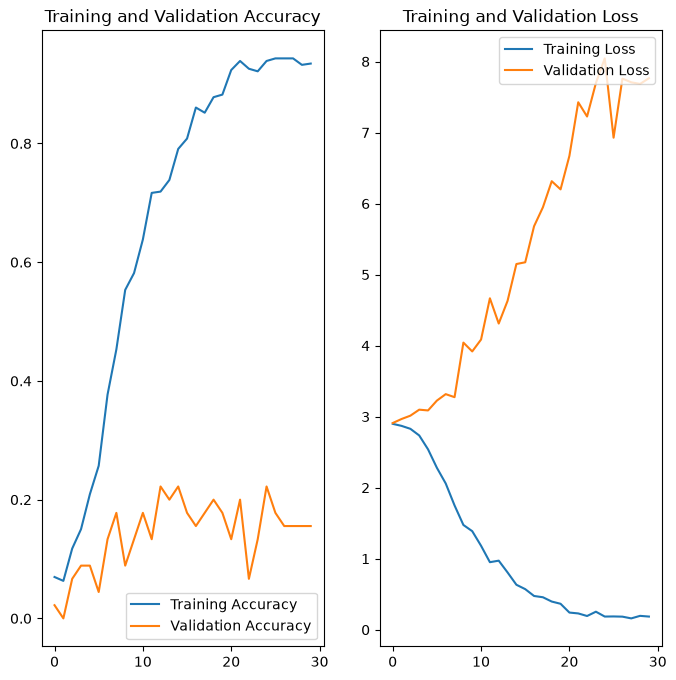

In [ ]:
training_accuracy = history.history["accuracy"]
validation_accuracy = history.history["val_accuracy"]

training_loss = history.history["loss"]
validation_loss = history.history["val_loss"]

epochs_range = range(NUM_EPOCHS)

plt.figure(figsize = (8, 8))
plt.subplot(1, 2, 1)

plt.plot(epochs_range, training_accuracy, label = "Training Accuracy")
plt.plot(epochs_range, validation_accuracy, label = "Validation Accuracy")

plt.legend(loc = "lower right")
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_loss, label = "Training Loss")
plt.plot(epochs_range, validation_loss, label = "Validation Loss")
plt.legend(loc = "upper right")

plt.title("Training and Validation Loss")
plt.show()

In [ ]:
model.save("asl_model.keras")
print("Model saved to asl_model.keras")

Model saved to asl_model.keras


## Archive idk

In [ ]:
# img_count = len(list(train_dir.glob("*/*.jpg")))
# print(img_count)

In [ ]:
# # img paths
# imgs_path = "Tensorflow/workspace/images/collected_images"

In [ ]:
# labels = ["hello", "thanks", "iloveyou", "yes", "no"]
# number_imgs = 15 # rn we'll use 15 images per label to train the model

In [ ]:
# # now to actually collect the images
# for label in labels:
#     !mkdir {"Tensorflow/workspace/images/collected_images/" + label} # this makes a new directory for each label - one for each label defined above
#     cap = cv2.VideoCapture(0) # turns on webcam with cv2's video capture method

#     print("Collecting images for " + str(label)) # print out ur collecting imgs for whatever label you're up to
#     time.sleep(5) # 5 seconds to get ready w/ the pose

#     for imgnum in range(number_imgs):
#         ret, frame = cap.read() # set up our capture (we're interested in the frame of the image)
#         imagename = os.path.join(imgs_path, label, label + "." + "{}.jpg".format(str(uuid.uuid1()))) # define it at image name. this is the entire path to our image
#         # os.path.join joins everything together so it could look like: "Tensorflow/workspace/images/collected_images/iloveyou/luvya_image2.jpg"
#         # the uuid.uuid1 makes sure each image has a unique identifier and nothing is duplicated
#         cv2.imwrite(imagename, frame) # write it to that directory (imagename = directory)
#         cv2.imshow("frame", frame) # also gotta show it to the screen so the viewer can see it
#         time.sleep(2) # 2 seconds buffer time to get into another pose

#         # implementing a "stop" function
#         if cv2.waitKey(1) & 0xFF == ord("q"):
#             break

#     cap.release()
